# 🐧 Penguins EDA — Matplotlib Fundamentals

Work through this notebook top to bottom. Every code cell has `TODO` markers — fill in the logic yourself.

**Golden rule for this project:** every plot starts with `fig, ax = plt.subplots()`. No shortcuts.

In [1]:
# Everything you need is imported for you.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # only used to load the dataset!

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Step 1 — Inspect the data

Before plotting anything, answer: How many rows? What dtypes? Any missing values?

Useful methods: `.info()`, `.describe()`, `.isna().sum()`

In [3]:
# TODO: print the basic info about the DataFrame
display(df.info())
# TODO: show summary statistics of the numeric columns
display(df.describe().T)
# TODO: count missing values per column
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


None

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Step 2 — Clean

A handful of rows have missing measurements. For this EDA, drop them and store the result back into `df`. Check the row count before and after so you know how much you lost.

In [8]:
# TODO: drop rows with missing values (keep the variable name df)
shape_before = df.shape
df_clean =  df.dropna()
# TODO: verify there are no NaNs left and print the new shape
print(df_clean.isna().sum())
shape_after = df_clean.shape

print(f"shape before: {shape_before}; shape after: {shape_after}")

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
shape before: (344, 7); shape after: (333, 7)


## Step 3 — Your first matplotlib plot: histogram

Plot the distribution of `body_mass_g`.

Pattern reminder:
```
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(<the column>, bins=<try a few values>)
ax.set_xlabel(...); ax.set_ylabel(...); ax.set_title(...)
plt.show()
```
(In lets-plot this would be `ggplot(df) + geom_histogram(aes(x=body_mass_g))` — here YOU manage the figure.)

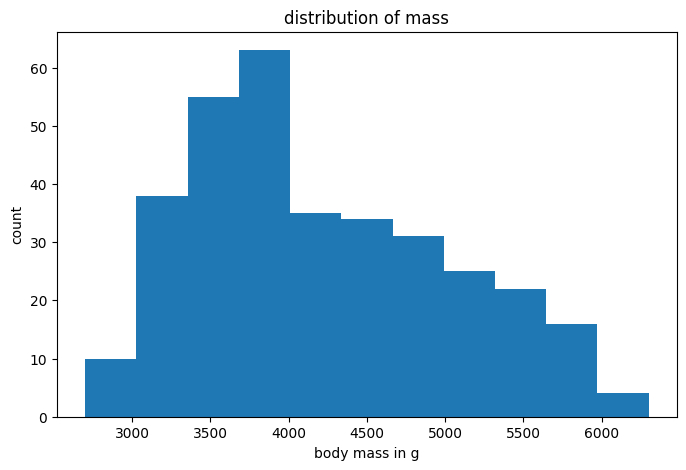

In [16]:
# TODO: histogram of body_mass_g with axis labels and a title
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean["body_mass_g"], bins="fd")
ax.set_xlabel("body mass in g"); ax.set_ylabel("count"); ax.set_title("distribution of mass")
plt.show()

## Step 4 — Scatter plot, colored by species

Plot `flipper_length_mm` (x) vs `body_mass_g` (y), one color per species.

There is no `aes(color=...)` in matplotlib! Instead, loop:
```
for species, group in df.groupby("species"):
    ax.scatter(..., ..., label=species, alpha=0.7)
ax.legend()
```

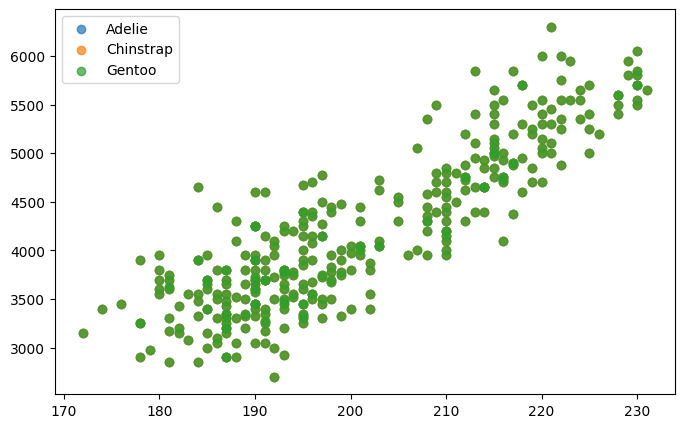

In [ ]:
# TODO: scatter plot of flipper_length_mm vs body_mass_g, colored by species
# Don't forget: labels, title, legend
fig, ax = plt.subplots(figsize=(8, 5))
for species, group in df.groupby("species"):
    ax.scatter(x=df["flipper_length_mm"], y=df["body_mass_g"], label=species, alpha=0.7)
ax.legend()

**Question to answer in this markdown cell (double-click to edit):** Which species stands out, and in what way?

*Your answer:* ...

## Step 5 — Bar chart of penguins per island

matplotlib does NOT aggregate for you. First compute the counts with `df["island"].value_counts()`, then pass `counts.index` and `counts.values` to `ax.bar(...)`.

In [ ]:
# TODO: compute counts per island

# TODO: bar chart of those counts


## Step 6 — Box plots of bill length per species

`ax.boxplot()` expects a *list of arrays* — one array of `bill_length_mm` values per species. Build that list first, then pass `tick_labels=` (or use `ax.set_xticklabels`) so the boxes are labeled.

In [ ]:
# TODO: build a list with one bill_length_mm array per species

# TODO: box plot with species names on the x-axis


## Step 7 — Subplots: a 2×2 dashboard

Combine your four plots into one figure:
```
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
```
`axes` is a 2D array → `axes[0, 0]` is top-left. Draw one of your four charts on each. Finish with `fig.tight_layout()`.

In [ ]:
# TODO: 2x2 subplot grid with histogram, scatter, bar chart, and box plot


## Step 8 — Polish and save your best figure

Take the figure you're proudest of, make it presentation-ready (clear title, readable labels, legend if needed), and save it:
```
fig.savefig("../outputs/figures/penguins_final.png", dpi=150, bbox_inches="tight")
```

In [ ]:
# TODO: recreate your best figure and save it to ../outputs/figures/


## 🎉 Done!

Go back to the README and tick off the completion checklist. If you can explain Figure vs Axes to a rubber duck, you've earned the next project.